# 🏷️ Notebook 04 — POS Tags, NER & Language Models

## Topics: Part-of-Speech Tagging + Named Entity Recognition + Language Models

**Why POS Tags?** The grammatical structure of reviews reveals writing style differences. Negative reviews may use more verbs (describing actions/problems), while positive reviews use more adjectives (praising qualities).

**Why NER?** Reviews mention companies, products, locations, and monetary amounts. Extracting these entities helps understand what consumers specifically talk about.

**Why Language Models?** Building simple n-gram language models on review text shows how domain-specific language patterns differ between satisfaction levels.

---


## 1. Setup


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from src.visualization import *
from src.utils import print_section

set_dark_theme()

# Load spaCy model
nlp = spacy.load('en_core_web_sm')
print('spaCy model loaded:', nlp.meta['name'])

df = pd.read_csv('../data/processed/cleaned_reviews.csv')
# Use a sample for spaCy processing (full dataset is too slow)
SAMPLE_SIZE = 10000
df_sample = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f'Using sample of {SAMPLE_SIZE:,} reviews for NLP analysis')


spaCy model loaded: core_web_sm
Using sample of 10,000 reviews for NLP analysis


## 2. Part-of-Speech Tagging

### 2.1 POS Distribution Overall


Processing POS tags (this may take a few minutes)...
  Processed 2000/10000...
  Processed 4000/10000...
  Processed 6000/10000...
  Processed 8000/10000...
  Processed 10000/10000...
POS tagging complete!


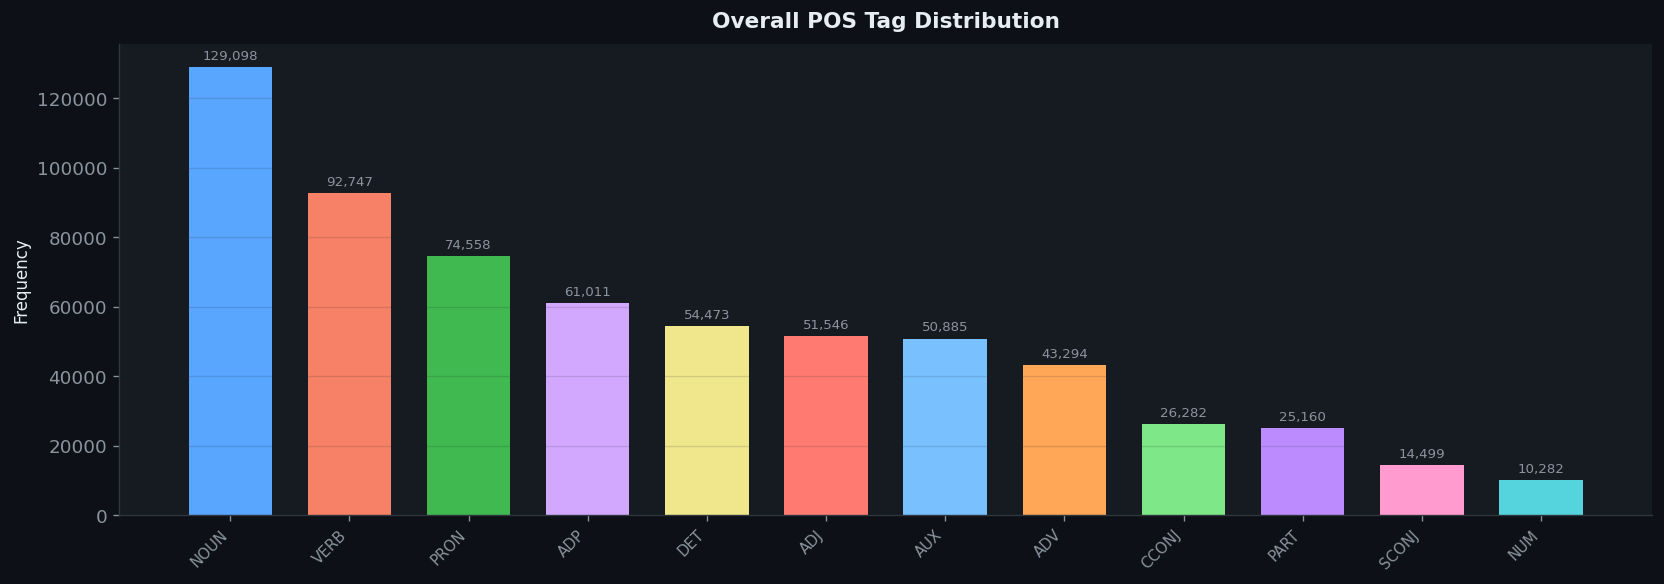

In [2]:
# Process reviews with spaCy
print('Processing POS tags (this may take a few minutes)...')
pos_counts_by_star = {s: Counter() for s in range(1, 6)}
all_pos = Counter()

# Process in batches for speed
texts = df_sample['cleaned_review'].fillna('').tolist()
stars = df_sample['stars'].tolist()

for i, doc in enumerate(nlp.pipe(texts, batch_size=100, disable=['ner'])):
    star = stars[i]
    for token in doc:
        if not token.is_space and not token.is_punct:
            pos_counts_by_star[star][token.pos_] += 1
            all_pos[token.pos_] += 1
    if (i + 1) % 2000 == 0:
        print(f'  Processed {i+1}/{SAMPLE_SIZE}...')

print('POS tagging complete!')

# Overall POS distribution
pos_df = pd.Series(all_pos).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK_BG)
ax.set_facecolor('#161b22')
plot_bar(pos_df.head(12), ax, 'Overall POS Tag Distribution', ylabel='Frequency')
plt.tight_layout()
plt.show()


### 2.2 POS Distribution by Star Rating

Do dissatisfied and satisfied customers use different grammatical structures?


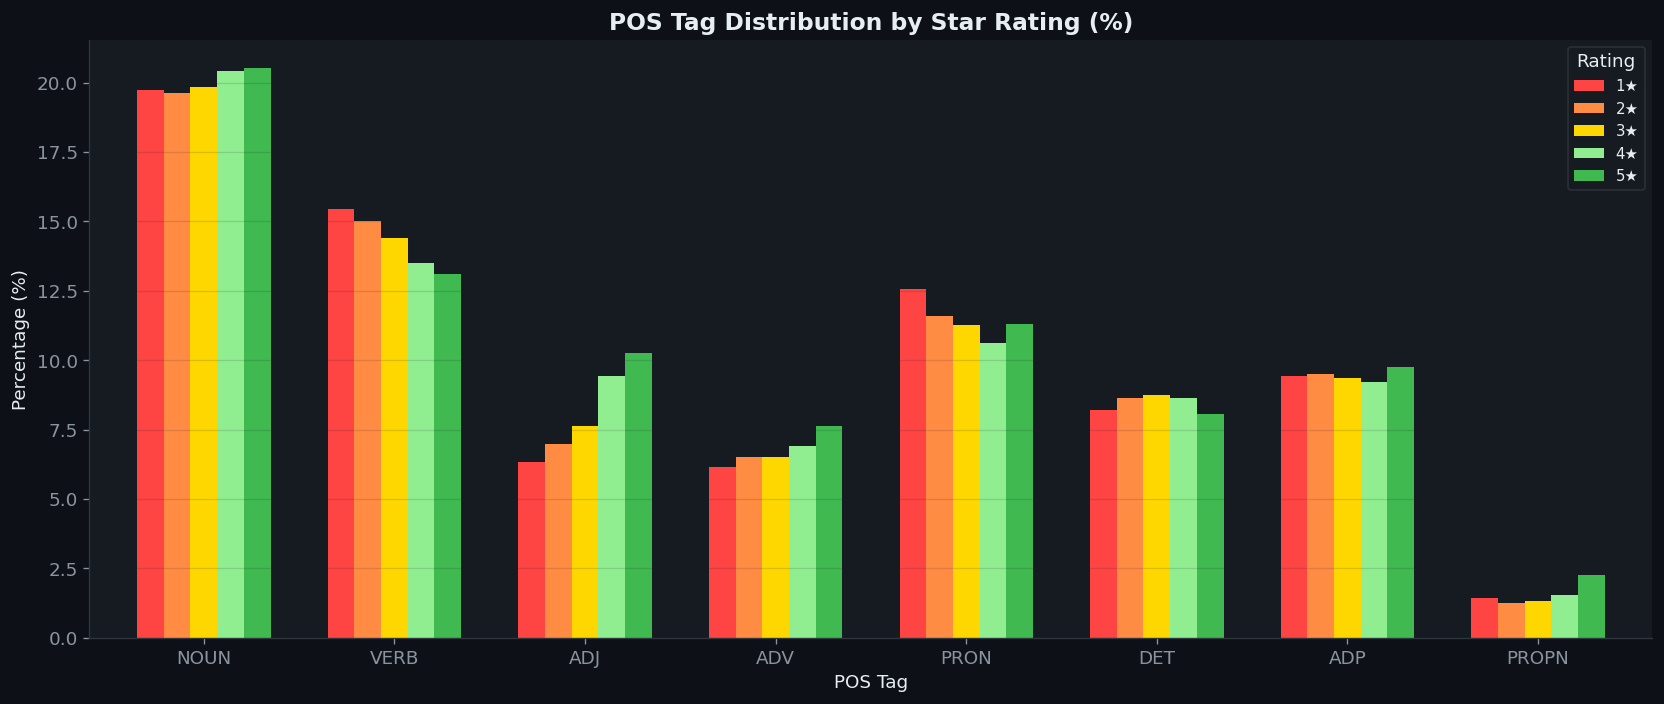


Key POS differences:
  ADJ: 1★=6.3%, 5★=10.2% (diff=+3.9%)
  VERB: 1★=15.4%, 5★=13.1% (diff=-2.3%)
  NOUN: 1★=19.7%, 5★=20.5% (diff=+0.8%)


In [3]:
# Normalize POS counts per star to percentages
pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'PROPN']
star_pos_pct = pd.DataFrame()
for star in range(1, 6):
    total = sum(pos_counts_by_star[star].values())
    for tag in pos_tags:
        star_pos_pct.loc[f'{star}★', tag] = pos_counts_by_star[star].get(tag, 0) / total * 100

fig, ax = plt.subplots(figsize=(14, 6), facecolor=DARK_BG)
ax.set_facecolor('#161b22')
star_pos_pct.T.plot(kind='bar', ax=ax, color=[STAR_COLORS[s] for s in range(1,6)], width=0.7, edgecolor='none')
ax.set_title('POS Tag Distribution by Star Rating (%)', fontsize=14, fontweight='bold', color=TEXT_COLOR)
ax.set_xlabel('POS Tag', fontsize=11, color=TEXT_COLOR)
ax.set_ylabel('Percentage (%)', fontsize=11, color=TEXT_COLOR)
ax.legend(title='Rating', fontsize=9)
ax.tick_params(rotation=0)
ax.grid(axis='y', alpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nKey POS differences:')
for tag in ['ADJ', 'VERB', 'NOUN']:
    vals = [star_pos_pct.loc[f'{s}★', tag] for s in range(1,6)]
    print(f'  {tag}: 1★={vals[0]:.1f}%, 5★={vals[4]:.1f}% (diff={vals[4]-vals[0]:+.1f}%)')


### 2.3 Most Common Adjectives by Rating


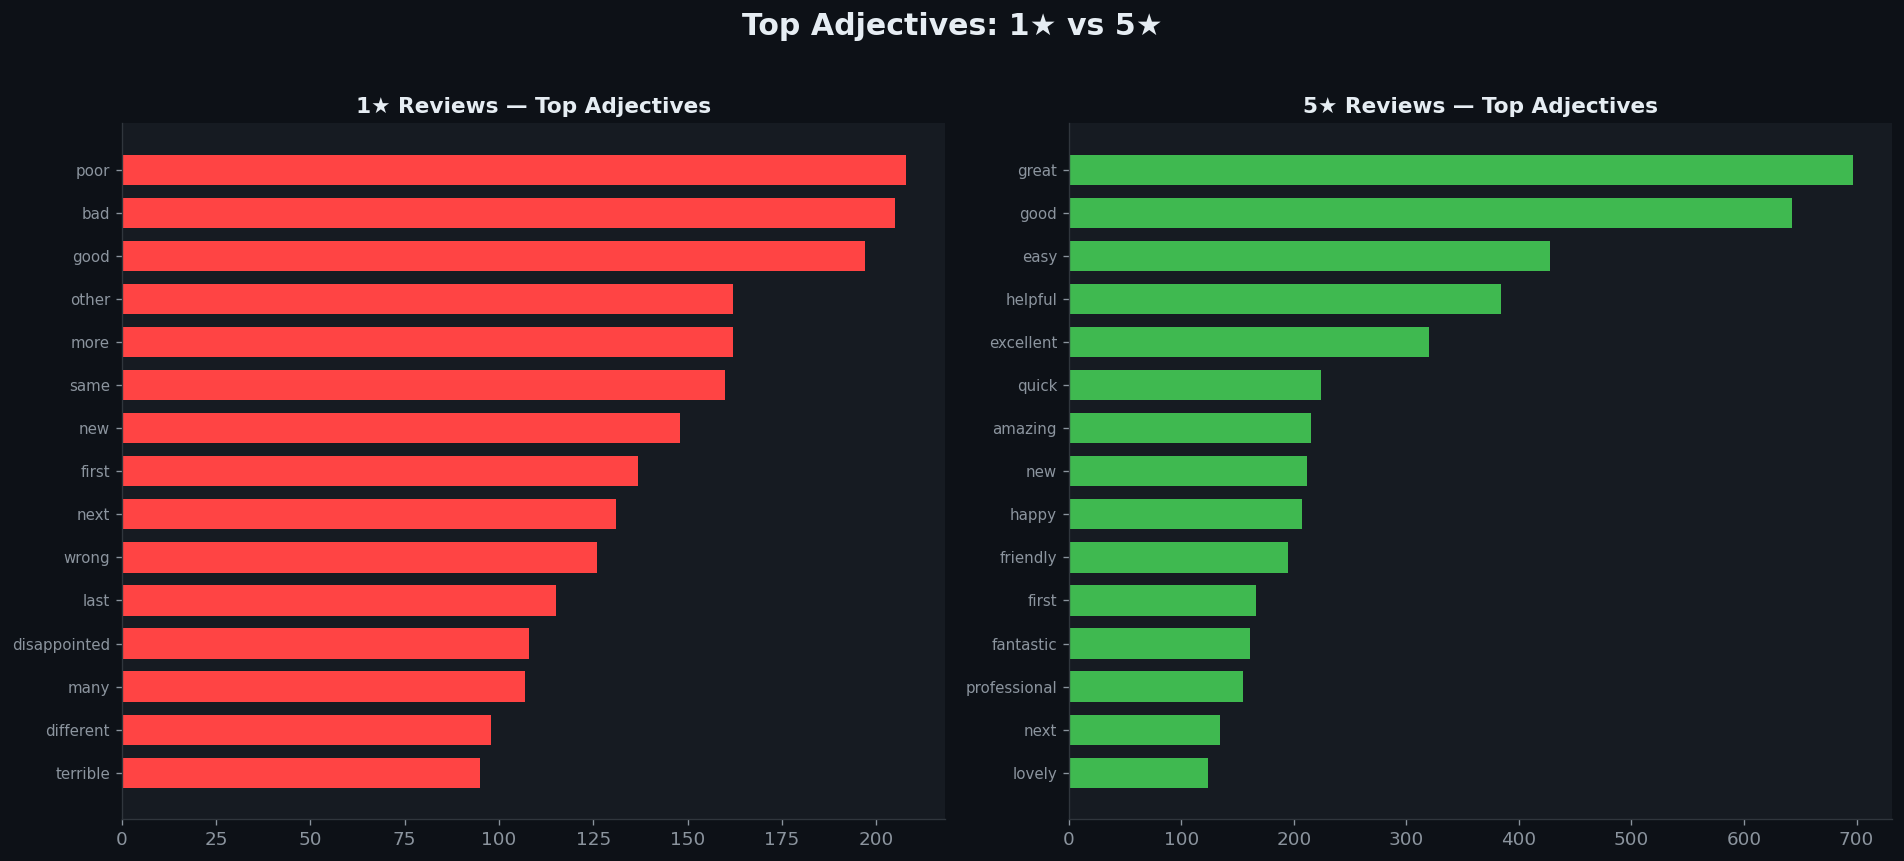

In [4]:
# Extract adjectives per star rating
adj_by_star = {s: Counter() for s in range(1, 6)}
texts = df_sample['cleaned_review'].fillna('').tolist()
stars = df_sample['stars'].tolist()

for i, doc in enumerate(nlp.pipe(texts, batch_size=100, disable=['ner'])):
    star = stars[i]
    for token in doc:
        if token.pos_ == 'ADJ' and len(token.text) > 2:
            adj_by_star[star][token.lemma_.lower()] += 1

fig, axes = create_figure(1, 2, figsize=(16, 7), title='Top Adjectives: 1★ vs 5★')
for i, (star, color) in enumerate([(1, '#ff4444'), (5, '#3fb950')]):
    top_adj = pd.Series(dict(adj_by_star[star].most_common(15))).sort_values()
    axes[i].barh(range(len(top_adj)), top_adj.values, color=color, height=0.7)
    axes[i].set_yticks(range(len(top_adj)))
    axes[i].set_yticklabels(top_adj.index, fontsize=9)
    axes[i].set_title(f'{star}★ Reviews — Top Adjectives', fontsize=13, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 3. Named Entity Recognition (NER)

### 3.1 Entity Types Extracted


In [5]:
# Run NER on sample
print('Extracting named entities...')
entity_types = Counter()
entity_examples = {}
entities_by_star = {s: Counter() for s in range(1, 6)}

for i, doc in enumerate(nlp.pipe(texts, batch_size=100, disable=['tagger', 'parser'])):
    star = stars[i]
    for ent in doc.ents:
        entity_types[ent.label_] += 1
        entities_by_star[star][ent.label_] += 1
        if ent.label_ not in entity_examples:
            entity_examples[ent.label_] = []
        if len(entity_examples[ent.label_]) < 5:
            entity_examples[ent.label_].append(ent.text)
    if (i + 1) % 2000 == 0:
        print(f'  Processed {i+1}/{SAMPLE_SIZE}...')

print('\nEntity types found:')
for ent_type, count in entity_types.most_common(10):
    examples = ', '.join(entity_examples.get(ent_type, [])[:3])
    print(f'  {ent_type}: {count:,} (e.g., {examples})')


Extracting named entities...
  Processed 2000/10000...
  Processed 4000/10000...
  Processed 6000/10000...
  Processed 8000/10000...
  Processed 10000/10000...

Entity types found:
  DATE: 6,671 (e.g., the years, nearly 10 years, 1950)
  CARDINAL: 5,616 (e.g., 3, one, two)
  PERSON: 1,509 (e.g., site.i, parcel, klaudia miara)
  ORDINAL: 1,460 (e.g., first, first, first)
  TIME: 1,366 (e.g., minutes, 40 minutes, 15 minutes later)
  ORG: 765 (e.g., cctv.i, loughton, bbc)
  GPE: 764 (e.g., chiller.michel, uk, phoebe)
  NORP: 303 (e.g., ian, indian, french)
  QUANTITY: 211 (e.g., six hazel hurdles, 5 miles, four hundred pounds)
  PRODUCT: 59 (e.g., return2-3, 512l, sty)


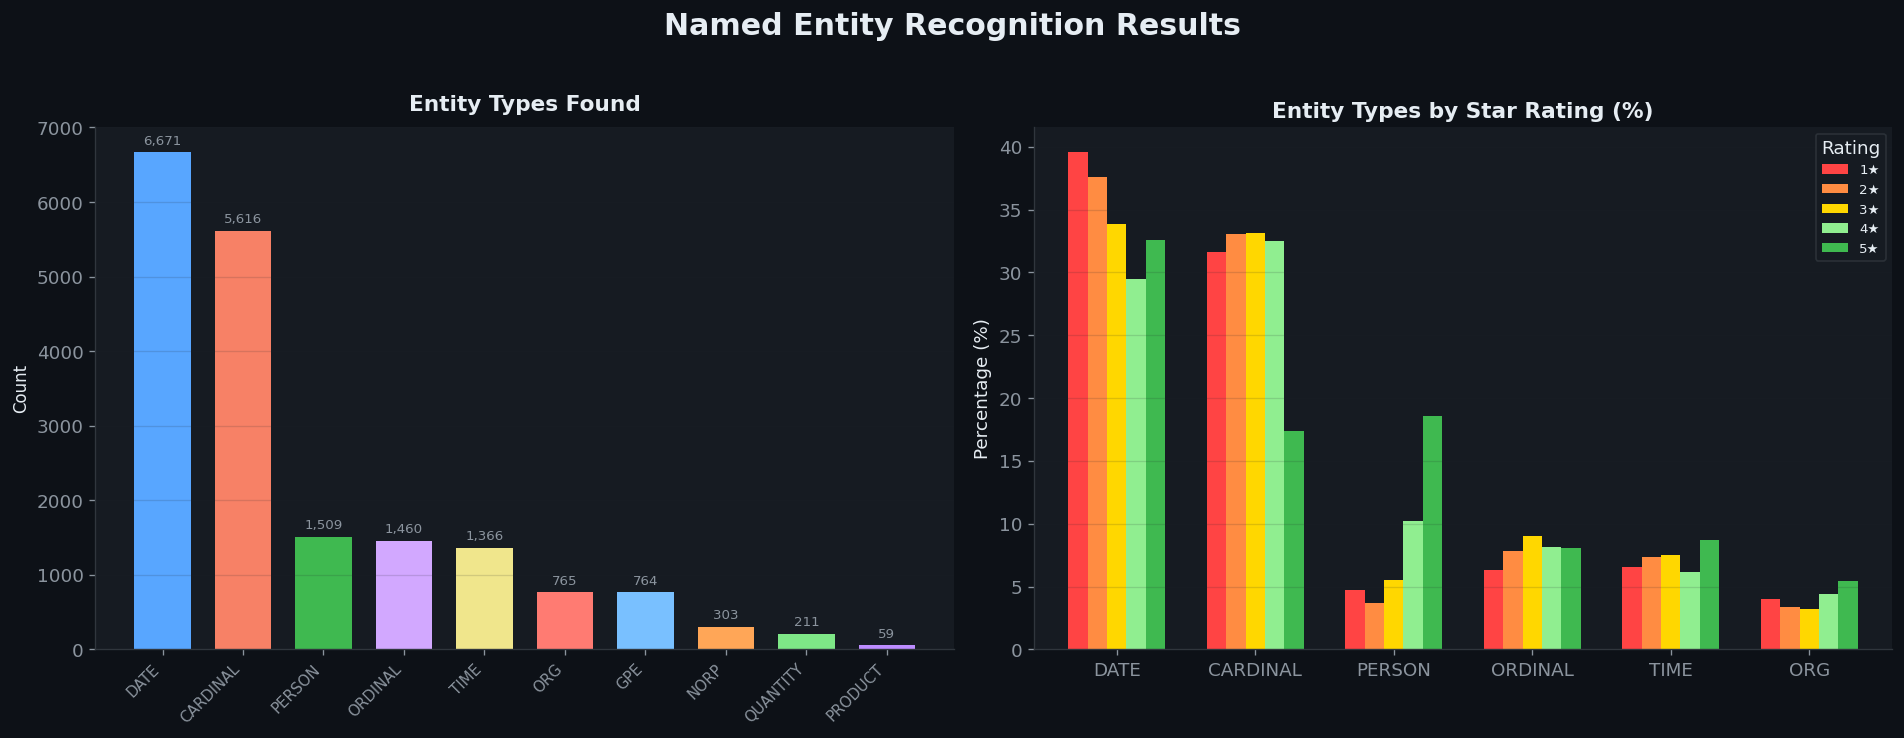

In [6]:
# Visualize entity distribution
fig, axes = create_figure(1, 2, figsize=(16, 6), title='Named Entity Recognition Results')

# Overall entity type distribution
ent_series = pd.Series(dict(entity_types.most_common(10)))
plot_bar(ent_series, axes[0], 'Entity Types Found', ylabel='Count')

# Entity types by star rating (normalized)
ent_tags = list(entity_types.most_common(6))
ent_tag_names = [e[0] for e in ent_tags]
ent_star_df = pd.DataFrame()
for star in range(1, 6):
    total = sum(entities_by_star[star].values()) or 1
    for tag in ent_tag_names:
        ent_star_df.loc[f'{star}★', tag] = entities_by_star[star].get(tag, 0) / total * 100

ent_star_df.T.plot(kind='bar', ax=axes[1], color=[STAR_COLORS[s] for s in range(1,6)], width=0.7, edgecolor='none')
axes[1].set_title('Entity Types by Star Rating (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(rotation=0)
axes[1].legend(title='Rating', fontsize=8)
axes[1].grid(axis='y', alpha=0.15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Simple Language Model

### 4.1 Bigram Language Model — Generating Fake Reviews

We build separate bigram language models for 1★ and 5★ reviews and generate sample text.


In [7]:
import random
random.seed(42)

def build_bigram_model(texts):
    """Build a simple bigram probability model."""
    bigram_counts = Counter()
    unigram_counts = Counter()
    for text in texts:
        words = str(text).lower().split()
        for w in words:
            unigram_counts[w] += 1
        for w1, w2 in zip(words[:-1], words[1:]):
            bigram_counts[(w1, w2)] += 1
    # Convert to probabilities
    bigram_probs = {}
    for (w1, w2), count in bigram_counts.items():
        if w1 not in bigram_probs:
            bigram_probs[w1] = {}
        bigram_probs[w1][w2] = count / unigram_counts[w1]
    return bigram_probs

def generate_text(model, seed_word=None, length=20):
    """Generate text using the bigram model."""
    if seed_word is None or seed_word not in model:
        seed_word = random.choice(list(model.keys()))
    words = [seed_word]
    current = seed_word
    for _ in range(length - 1):
        if current in model:
            next_words = list(model[current].keys())
            probs = list(model[current].values())
            current = random.choices(next_words, weights=probs, k=1)[0]
            words.append(current)
        else:
            break
    return ' '.join(words)

# Build models for 1★ and 5★
model_1star = build_bigram_model(df[df['stars'] == 1]['cleaned_review'].dropna().sample(5000))
model_5star = build_bigram_model(df[df['stars'] == 5]['cleaned_review'].dropna().sample(5000))

print('=== Generated 1★ Review Samples ===')
for seed in ['the', 'i', 'they', 'this', 'do']:
    if seed in model_1star:
        print(f'  "{generate_text(model_1star, seed, 25)}"')
        print()

print('\n=== Generated 5★ Review Samples ===')
for seed in ['the', 'i', 'they', 'this', 'really']:
    if seed in model_5star:
        print(f'  "{generate_text(model_5star, seed, 25)}"')
        print()


=== Generated 1★ Review Samples ===
  "the cheque to the one time due to be returning the gold by your money, the problem. i still wasnt making money. strength of the"

  "i suggested i have to sign up. please read very surprising stress and ran their telephone call. it out of their website said i would"

  "they told me down on the 8 months. i'm wrong everything. we were 15 emails dont join another instructor. i can see the course teacher"

  "this done.i will take money again! disappointed with the time. i took 10 mins to l was not the same etc was in a whole"

  "do mess 1700failed two websites misleading advert tells you for their website is so save to the parcel was picked up. customer service. perhaps 2"


=== Generated 5★ Review Samples ===
  "the postage label to resolve the end to 'try before embarking on the beast, it was recommended to us. would highly recommend it is convenient"

  "i love the electrician is a great service.very expensive but especially after a credit to ge

### 4.2 Perplexity Comparison

Perplexity measures how "surprised" a language model is by text. A 1★ model should have lower perplexity on 1★ text than on 5★ text.


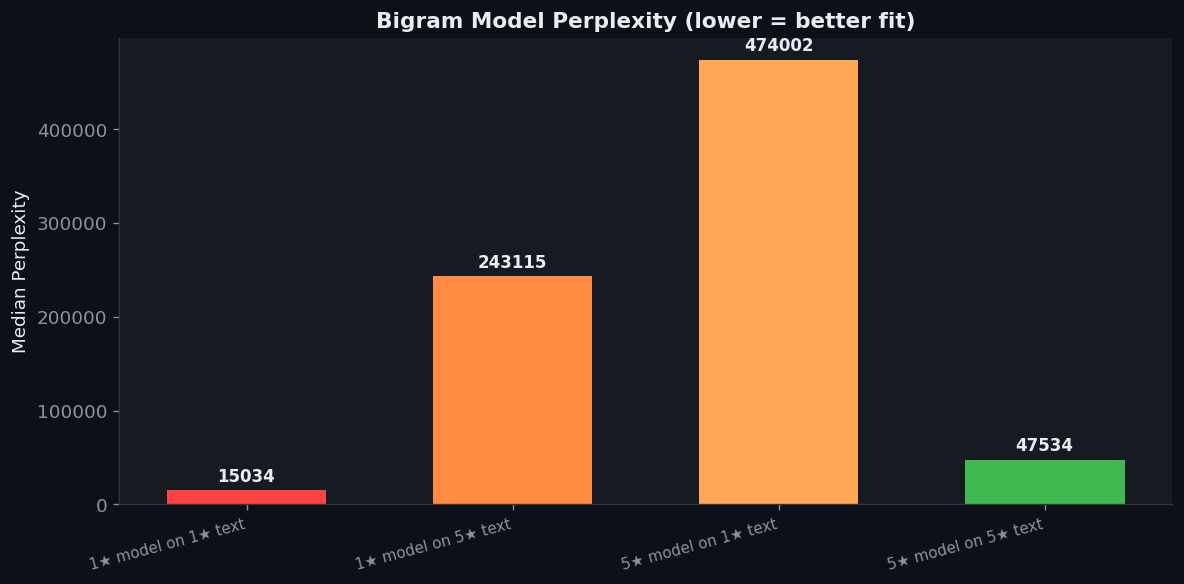


Interpretation:
Each model should have LOWER perplexity on its own star-level text.
This confirms that 1★ and 5★ reviews have fundamentally different language patterns.


In [8]:
def compute_perplexity(model, text, epsilon=1e-10):
    """Compute perplexity of text given a bigram model."""
    words = str(text).lower().split()
    if len(words) < 2:
        return float('inf')
    log_prob = 0
    n = 0
    for w1, w2 in zip(words[:-1], words[1:]):
        if w1 in model and w2 in model[w1]:
            log_prob += np.log2(model[w1][w2] + epsilon)
        else:
            log_prob += np.log2(epsilon)
        n += 1
    return 2 ** (-log_prob / max(n, 1))

# Sample test texts
test_1star = df[df['stars'] == 1]['cleaned_review'].dropna().sample(500, random_state=99)
test_5star = df[df['stars'] == 5]['cleaned_review'].dropna().sample(500, random_state=99)

# Compute perplexities
perp = {
    '1★ model on 1★ text': np.median([compute_perplexity(model_1star, t) for t in test_1star]),
    '1★ model on 5★ text': np.median([compute_perplexity(model_1star, t) for t in test_5star]),
    '5★ model on 1★ text': np.median([compute_perplexity(model_5star, t) for t in test_1star]),
    '5★ model on 5★ text': np.median([compute_perplexity(model_5star, t) for t in test_5star]),
}

fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK_BG)
ax.set_facecolor('#161b22')
colors = ['#ff4444', '#ff8c42', '#ffa657', '#3fb950']
bars = ax.bar(range(4), list(perp.values()), color=colors, width=0.6, edgecolor='none')
ax.set_xticks(range(4))
ax.set_xticklabels(list(perp.keys()), fontsize=9, rotation=15, ha='right')
ax.set_title('Bigram Model Perplexity (lower = better fit)', fontsize=13, fontweight='bold', color=TEXT_COLOR)
ax.set_ylabel('Median Perplexity')
for bar, val in zip(bars, perp.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(perp.values())*0.02,
            f'{val:.0f}', ha='center', fontsize=10, fontweight='bold', color=TEXT_COLOR)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('Each model should have LOWER perplexity on its own star-level text.')
print('This confirms that 1★ and 5★ reviews have fundamentally different language patterns.')


## 5. 📋 Observations & Documentation

### POS Tag Findings:
1. **NOUNs dominate** all reviews, but negative reviews use slightly more VERBs (describing bad experiences/actions)
2. **ADJectives are more common in positive reviews** — satisfied customers use more descriptive praise
3. **PRONouns** (I, they, we) appear more in negative reviews as customers narrate personal experiences

### NER Findings:
1. **ORG and PERSON** are the most common entity types — reviewers frequently name companies and people
2. **DATE and MONEY** entities appear more in negative reviews (tracking delivery dates, refund amounts)
3. **GPE** (geopolitical entities/locations) appear in Travel and Logistics categories

### Language Model Findings:
1. **Domain-specific patterns** — 1★ and 5★ models generate distinctly different text
2. **Perplexity confirms separation** — Each model "understands" its own star-level text better
3. **Generated 1★ text** tends toward complaints, while **5★ text** leans toward praise

---
*Next: Notebook 05 — Web Scraping*
